# Lorenz avec donnees incompletes: X et Y manquants

Convention du fichier: X et Y sont manquants. Seule la composante Z(t) est observee; le PINN reconstruit X(t) et Y(t) via les equations de Lorenz.


## 1. Imports et configuration


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from mpl_toolkits.mplot3d import Axes3D

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

print(f"Device: {device}")
print(f"Dtype: {dtype}")


Device: cpu
Dtype: torch.float32


## 2. Systeme de Lorenz et reference RK45


In [2]:
# Parametres classiques du systeme de Lorenz
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

def lorenz(t, state):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

# Reference numerique RK45 haute precision
T = 10.0
n_ref = 2000
t_eval = np.linspace(0.0, T, n_ref)
u0_np = np.array([1.0, 1.0, 1.0], dtype=np.float64)

sol = solve_ivp(
    lorenz,
    (0.0, T),
    u0_np,
    method="RK45",
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12,
    dense_output=True,
)

if not sol.success:
    raise RuntimeError(sol.message)

U_ref = sol.y.T
x_ref, y_ref, z_ref = U_ref[:, 0], U_ref[:, 1], U_ref[:, 2]

# Normalisation des etats: chaque composante contribue de facon comparable.
u_mean_np = U_ref.mean(axis=0)
u_std_np = U_ref.std(axis=0)
u_std_np = np.where(u_std_np < 1e-12, 1.0, u_std_np)
u0_norm_np = (u0_np - u_mean_np) / u_std_np

print("Reference RK45")
print(f"  Intervalle: [0, {T}]")
print(f"  Points: {n_ref}")
print(f"  Condition initiale: {u0_np}")
print(f"  Moyenne etats: {u_mean_np}")
print(f"  Ecart-type etats: {u_std_np}")


Reference RK45
  Intervalle: [0, 10.0]
  Points: 2000
  Condition initiale: [1. 1. 1.]
  Moyenne etats: [-7.35909634 -7.41781443 26.31704759]
  Ecart-type etats: [4.27368757 4.95864907 5.25571568]


## 3. Preparation des donnees


In [3]:
OBSERVED_IDX = [2]
MISSING_IDX = [0, 1]

# Poids de perte. Les donnees sont en variables normalisees.
# Curriculum:
# 1) warm-up donnees + petite contrainte physique;
# 2) ajout progressif de la contrainte differentielle forte;
# 3) raffinement L-BFGS.
PRETRAIN_DATA_WEIGHT = 20.0
PINN_DATA_WEIGHT = 20.0
LBFGS_DATA_WEIGHT = 20.0
PRETRAIN_ODE_WEIGHT = 0.02
ODE_START_WEIGHT = 0.05
FINAL_ODE_WEIGHT = 1.0

# Parametres d'optimisation.
PRETRAIN_EPOCHS = 500
PRETRAIN_LR = 1e-3
PINN_EPOCHS = 10000
PINN_LR = 5e-4
ODE_RAMP_EPOCHS = 5000
PRINT_EVERY = 1000

USE_LBFGS = False
LBFGS_MAX_ITER = 100
LBFGS_LR = 0.5


In [4]:
def t_to_tau_np(t):
    # Convertit t in [0,T] vers tau in [-1,1].
    return 2.0 * np.asarray(t) / T - 1.0

def tau_to_t_tensor(tau):
    # Convertit tau in [-1,1] vers t in [0,T].
    return 0.5 * T * (tau + 1.0)

def to_tensor(array, requires_grad=False):
    out = torch.tensor(array, dtype=dtype, device=device)
    out.requires_grad_(requires_grad)
    return out

# Points de donnees et points de collocation separes.
# 500 points physiques gardent un cout proche des anciens notebooks.
n_data = 500
n_phys = 500

data_idx = np.linspace(0, n_ref - 1, n_data, dtype=int)
t_data_np = t_eval[data_idx]
U_data_np = U_ref[data_idx]
U_data_norm_np = (U_data_np - u_mean_np) / u_std_np

tau_data = to_tensor(t_to_tau_np(t_data_np).reshape(-1, 1))
u_data_norm = to_tensor(U_data_norm_np)

tau_phys = torch.linspace(-1.0, 1.0, n_phys, dtype=dtype, device=device).reshape(-1, 1)
tau_phys.requires_grad_(True)

tau_eval = to_tensor(t_to_tau_np(t_eval).reshape(-1, 1))

u_mean = to_tensor(u_mean_np.reshape(1, 3))
u_std = to_tensor(u_std_np.reshape(1, 3))
u0_norm = to_tensor(u0_norm_np.reshape(1, 3))

component_names = np.array(["X", "Y", "Z"])
observed_names = component_names[OBSERVED_IDX].tolist()
missing_names = component_names[MISSING_IDX].tolist()

print(f"Composantes observees: {observed_names}")
print(f"Composantes reconstruites/cachees: {missing_names}")
print(f"Points donnees: {n_data}")
print(f"Points collocation physique: {n_phys}")


Composantes observees: ['Z']
Composantes reconstruites/cachees: ['X', 'Y']
Points donnees: 500
Points collocation physique: 500


## 4. Architectures PINN


In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, depth=4):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 3))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class LorenzPINN(nn.Module):
    # PINN avec condition initiale imposee exactement.
    # Le reseau predit des variables normalisees. La forme
    # u_norm(tau) = u0_norm + ((tau+1)/2) * NN(tau)
    # force u(0)=u0 lorsque tau=-1.
    def __init__(self, fourier=False, frequencies=(1, 2, 4, 8, 16, 32), hidden_dim=256, depth=4):
        super().__init__()
        self.fourier = fourier
        self.register_buffer("frequencies", torch.tensor(frequencies, dtype=dtype))
        input_dim = 1 + 2 * len(frequencies) if fourier else 1
        self.mlp = MLP(input_dim=input_dim, hidden_dim=hidden_dim, depth=depth)

    def features(self, tau):
        if not self.fourier:
            return tau
        # t/T = (tau+1)/2, donc angle = 2*pi*k*t/T = pi*k*(tau+1)
        angles = np.pi * (tau + 1.0) * self.frequencies.reshape(1, -1)
        return torch.cat([tau, torch.sin(angles), torch.cos(angles)], dim=1)

    def forward(self, tau):
        s = 0.5 * (tau + 1.0)
        raw = self.mlp(self.features(tau))
        return u0_norm + s * raw


def denormalize(u_norm):
    return u_norm * u_std + u_mean


model_std = LorenzPINN(fourier=False).to(device)
model_fourier = LorenzPINN(fourier=True).to(device)

print(f"Parametres PINN standard: {sum(p.numel() for p in model_std.parameters()):,}")
print(f"Parametres PINN-Fourier:  {sum(p.numel() for p in model_fourier.parameters()):,}")


Parametres PINN standard: 132,867
Parametres PINN-Fourier:  135,939


## 5. Entrainement Adam + L-BFGS


In [6]:
def lorenz_loss_terms(model):
    # Residus physiques sur les points de collocation.
    u_norm_phys = model(tau_phys)
    u_phys = denormalize(u_norm_phys)
    x, y, z = u_phys[:, 0:1], u_phys[:, 1:2], u_phys[:, 2:3]

    dx_dtau = torch.autograd.grad(x, tau_phys, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    dy_dtau = torch.autograd.grad(y, tau_phys, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    dz_dtau = torch.autograd.grad(z, tau_phys, grad_outputs=torch.ones_like(z), create_graph=True)[0]

    # tau = 2t/T - 1, donc d/dt = (2/T) d/dtau.
    dx_dt = (2.0 / T) * dx_dtau
    dy_dt = (2.0 / T) * dy_dtau
    dz_dt = (2.0 / T) * dz_dtau

    f1 = dx_dt - sigma * (y - x)
    f2 = dy_dt - (x * (rho - z) - y)
    f3 = dz_dt - (x * y - beta * z)

    # Mise a l'echelle des residus pour eviter qu'une composante domine.
    residual_scale = u_std.clamp_min(1e-6)
    residuals = torch.cat(
        [f1 / residual_scale[:, 0:1], f2 / residual_scale[:, 1:2], f3 / residual_scale[:, 2:3]],
        dim=1,
    )
    loss_ode = (residuals ** 2).mean()

    # Donnees observees seulement: complet pour Lorenz_Comparison, partiel sinon.
    u_norm_data_pred = model(tau_data)
    loss_data = ((u_norm_data_pred[:, OBSERVED_IDX] - u_data_norm[:, OBSERVED_IDX]) ** 2).mean()

    # Diagnostic uniquement: la CI est imposee exactement par construction.
    tau0 = torch.tensor([[-1.0]], dtype=dtype, device=device)
    loss_ic = ((model(tau0) - u0_norm) ** 2).mean()

    return {
        "ode": loss_ode,
        "data": loss_data,
        "ic": loss_ic,
    }


def weighted_loss(model, lambda_data, lambda_ode):
    terms = lorenz_loss_terms(model)
    loss = lambda_data * terms["data"] + lambda_ode * terms["ode"]
    return loss, terms


def append_history(history, loss, terms, stage, lambda_ode):
    history["loss"].append(float(loss.detach().cpu()))
    history["ode"].append(float(terms["ode"].detach().cpu()))
    history["data"].append(float(terms["data"].detach().cpu()))
    history["ic"].append(float(terms["ic"].detach().cpu()))
    history["stage"].append(stage)
    history["lambda_ode"].append(float(lambda_ode))


def train(model, label):
    history = {"loss": [], "ode": [], "data": [], "ic": [], "stage": [], "lambda_ode": []}

    # Phase 1: warm-up sur les observations RK45 avec une petite contrainte physique.
    # Dans les cas incomplets, les variables cachees ne doivent jamais rester
    # totalement libres: meme faible, le residu ODE les relie aux observations.
    optimizer = torch.optim.Adam(model.parameters(), lr=PRETRAIN_LR)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, PRETRAIN_EPOCHS // 2), gamma=0.5)
    print(f"\nWarm-up donnees + physique faible {label}")
    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        optimizer.zero_grad()
        loss, terms = weighted_loss(
            model,
            lambda_data=PRETRAIN_DATA_WEIGHT,
            lambda_ode=PRETRAIN_ODE_WEIGHT,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        append_history(history, loss, terms, "warmup", PRETRAIN_ODE_WEIGHT)

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            print(
                f"{label} | warmup {epoch:5d}/{PRETRAIN_EPOCHS} | "
                f"lambda_ode={PRETRAIN_ODE_WEIGHT:.2e} | "
                f"loss={history['loss'][-1]:.3e} | "
                f"ode={history['ode'][-1]:.3e} | "
                f"data={history['data'][-1]:.3e} | "
                f"ic={history['ic'][-1]:.3e}"
            )

    # Phase 2: curriculum PINN. Le poids du residu ODE augmente progressivement.
    optimizer = torch.optim.Adam(model.parameters(), lr=PINN_LR)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, PINN_EPOCHS // 4), gamma=0.5)
    print(f"\nEntrainement physique progressif {label}")
    for epoch in range(1, PINN_EPOCHS + 1):
        ramp = min(1.0, epoch / max(1, ODE_RAMP_EPOCHS))
        lambda_ode = ODE_START_WEIGHT + (FINAL_ODE_WEIGHT - ODE_START_WEIGHT) * ramp
        optimizer.zero_grad()
        loss, terms = weighted_loss(model, lambda_data=PINN_DATA_WEIGHT, lambda_ode=lambda_ode)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        append_history(history, loss, terms, "pinn", lambda_ode)

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            print(
                f"{label} | pinn {epoch:5d}/{PINN_EPOCHS} | "
                f"lambda_ode={lambda_ode:.2e} | "
                f"loss={history['loss'][-1]:.3e} | "
                f"ode={history['ode'][-1]:.3e} | "
                f"data={history['data'][-1]:.3e} | "
                f"ic={history['ic'][-1]:.3e}"
            )

    if USE_LBFGS:
        print(f"\nRaffinement {label} avec L-BFGS")
        lbfgs = torch.optim.LBFGS(
            model.parameters(),
            lr=LBFGS_LR,
            max_iter=LBFGS_MAX_ITER,
            max_eval=LBFGS_MAX_ITER,
            tolerance_grad=1e-9,
            tolerance_change=1e-11,
            history_size=50,
            line_search_fn="strong_wolfe",
        )

        def closure():
            lbfgs.zero_grad()
            loss, terms = weighted_loss(
                model,
                lambda_data=LBFGS_DATA_WEIGHT,
                lambda_ode=FINAL_ODE_WEIGHT,
            )
            loss.backward()
            return loss

        lbfgs.step(closure)
        final_loss, final_terms = weighted_loss(
            model,
            lambda_data=LBFGS_DATA_WEIGHT,
            lambda_ode=FINAL_ODE_WEIGHT,
        )
        append_history(history, final_loss, final_terms, "lbfgs", FINAL_ODE_WEIGHT)
        print(
            f"{label} apres L-BFGS | "
            f"loss={history['loss'][-1]:.3e} | "
            f"ode={history['ode'][-1]:.3e} | "
            f"data={history['data'][-1]:.3e} | "
            f"ic={history['ic'][-1]:.3e}"
        )

    return history


hist_std = train(model_std, "PINN standard")
hist_fourier = train(model_fourier, "PINN-Fourier")



Warm-up donnees + physique faible PINN standard
PINN standard | warmup     1/500 | lambda_ode=2.00e-02 | loss=4.847e+02 | ode=9.401e+00 | data=2.422e+01 | ic=0.000e+00

Entrainement physique progressif PINN standard
PINN standard | pinn     1/10000 | lambda_ode=5.02e-02 | loss=1.767e+01 | ode=4.325e+00 | data=8.726e-01 | ic=0.000e+00
PINN standard | pinn  1000/10000 | lambda_ode=2.40e-01 | loss=1.421e+01 | ode=3.633e+00 | data=6.667e-01 | ic=0.000e+00
PINN standard | pinn  2000/10000 | lambda_ode=4.30e-01 | loss=1.293e+01 | ode=4.012e+00 | data=5.602e-01 | ic=0.000e+00
PINN standard | pinn  3000/10000 | lambda_ode=6.20e-01 | loss=1.220e+01 | ode=3.680e+00 | data=4.961e-01 | ic=0.000e+00
PINN standard | pinn  4000/10000 | lambda_ode=8.10e-01 | loss=1.210e+01 | ode=3.375e+00 | data=4.686e-01 | ic=0.000e+00
PINN standard | pinn  5000/10000 | lambda_ode=1.00e+00 | loss=1.223e+01 | ode=3.189e+00 | data=4.521e-01 | ic=0.000e+00
PINN standard | pinn  6000/10000 | lambda_ode=1.00e+00 | loss=1

## 6. Evaluation quantitative


In [7]:
def predict(model):
    model.eval()
    with torch.no_grad():
        u_norm = model(tau_eval)
        u_pred = denormalize(u_norm).cpu().numpy()
    return u_pred


def metrics(U_pred):
    err = U_pred - U_ref
    mae = np.mean(np.abs(err), axis=0)
    rmse = np.sqrt(np.mean(err ** 2, axis=0))
    rel_l2 = np.linalg.norm(err, axis=0) / np.linalg.norm(U_ref, axis=0)
    global_rel_l2 = np.linalg.norm(err) / np.linalg.norm(U_ref)
    return err, mae, rmse, rel_l2, global_rel_l2


U_std = predict(model_std)
U_fourier = predict(model_fourier)

err_std, mae_std, rmse_std, rel_std, glob_std = metrics(U_std)
err_fourier, mae_fourier, rmse_fourier, rel_fourier, glob_fourier = metrics(U_fourier)

print("\n" + "=" * 80)
print("METRIQUES PAR RAPPORT A LA REFERENCE RK45")
print("=" * 80)

for name, mae, rmse, rel, glob in [
    ("PINN standard", mae_std, rmse_std, rel_std, glob_std),
    ("PINN-Fourier", mae_fourier, rmse_fourier, rel_fourier, glob_fourier),
]:
    print(f"\n{name}")
    for i, comp in enumerate(component_names):
        obs_flag = "observee" if i in OBSERVED_IDX else "cachee"
        print(
            f"  {comp} ({obs_flag}) | "
            f"MAE={mae[i]:.4e} | RMSE={rmse[i]:.4e} | RelL2={rel[i]:.4e}"
        )
    print(f"  RelL2 global={glob:.4e}")



METRIQUES PAR RAPPORT A LA REFERENCE RK45

PINN standard
  X (cachee) | MAE=1.7274e+00 | RMSE=3.9604e+00 | RelL2=4.6538e-01
  Y (cachee) | MAE=2.1177e+00 | RMSE=4.6502e+00 | RelL2=5.2117e-01
  Z (observee) | MAE=2.1172e+00 | RMSE=3.3055e+00 | RelL2=1.2317e-01
  RelL2 global=2.3516e-01

PINN-Fourier
  X (cachee) | MAE=7.7567e-01 | RMSE=3.8706e+00 | RelL2=4.5483e-01
  Y (cachee) | MAE=7.6452e-01 | RMSE=4.2872e+00 | RelL2=4.8049e-01
  Z (observee) | MAE=3.2562e-01 | RMSE=1.8711e+00 | RelL2=6.9723e-02
  RelL2 global=2.0558e-01


## 7. Visualisations


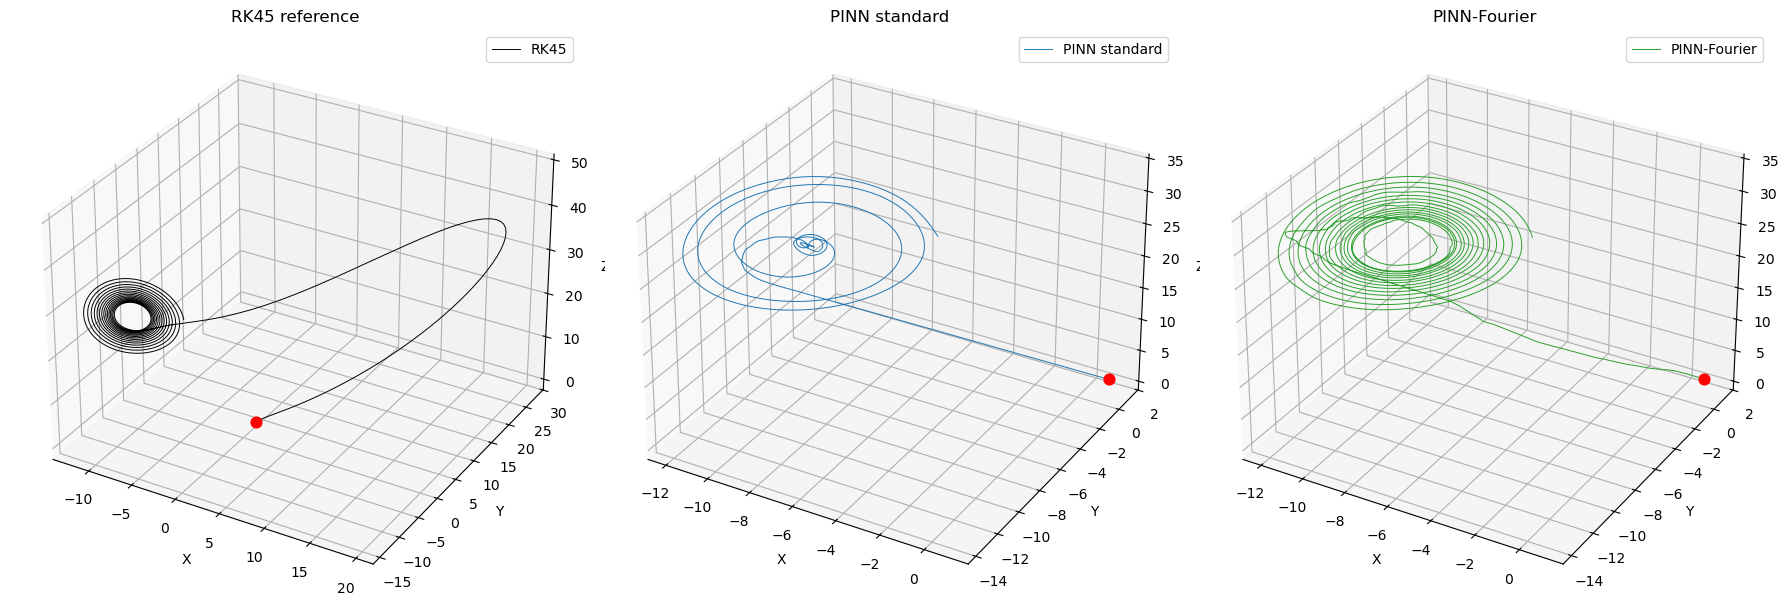

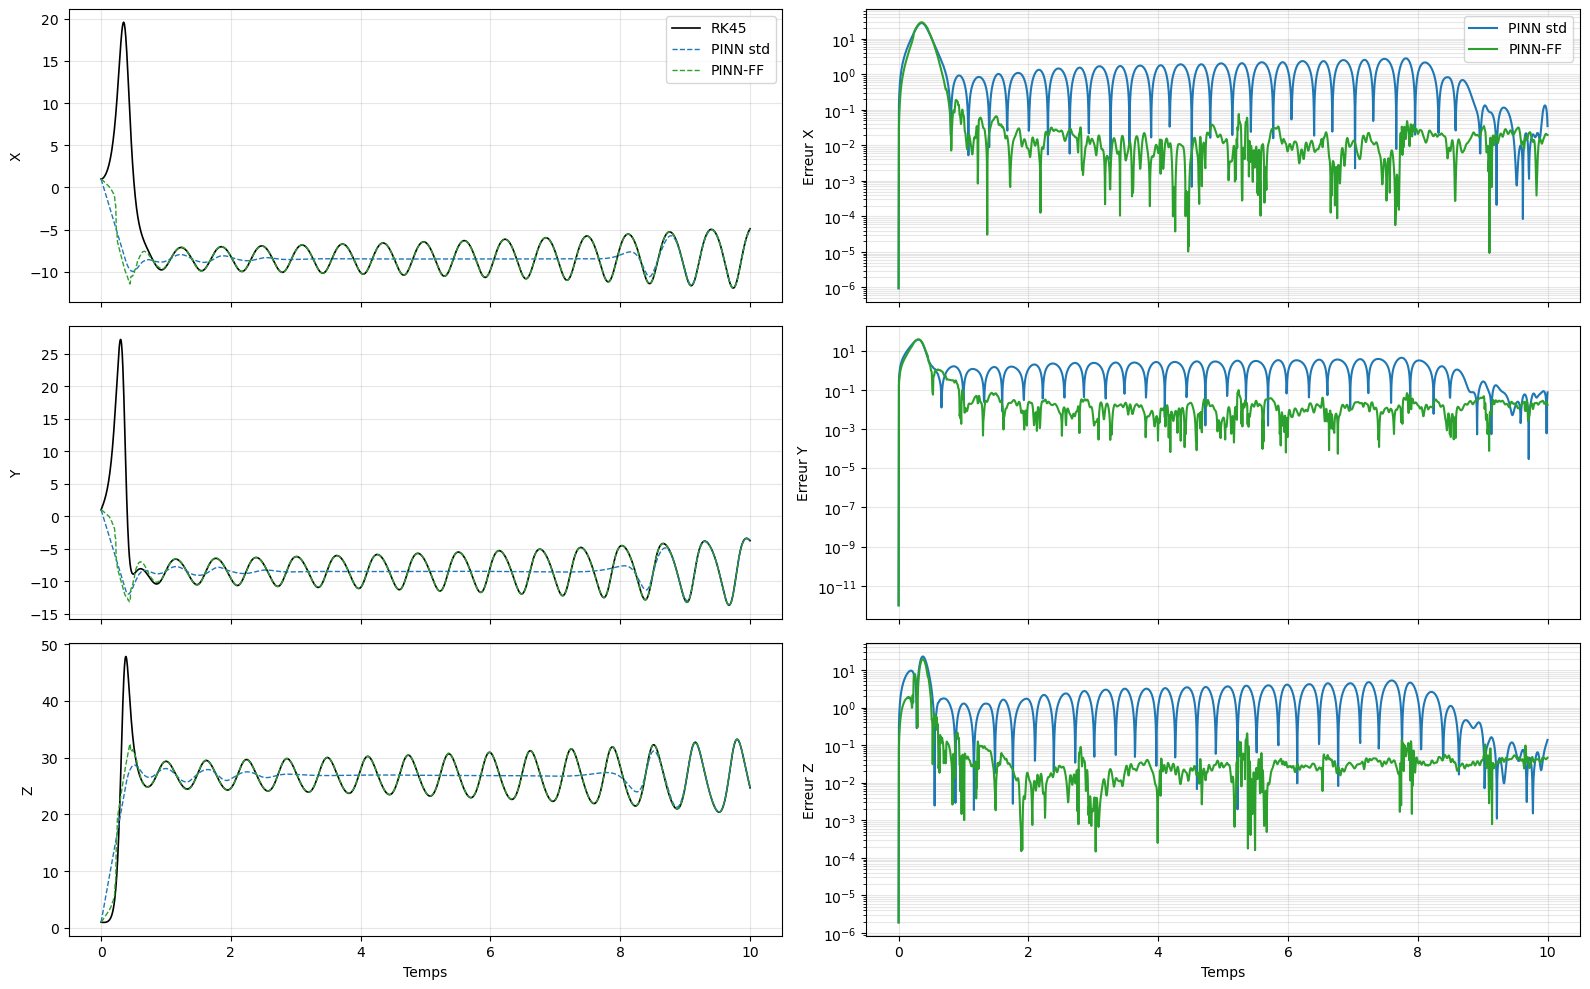

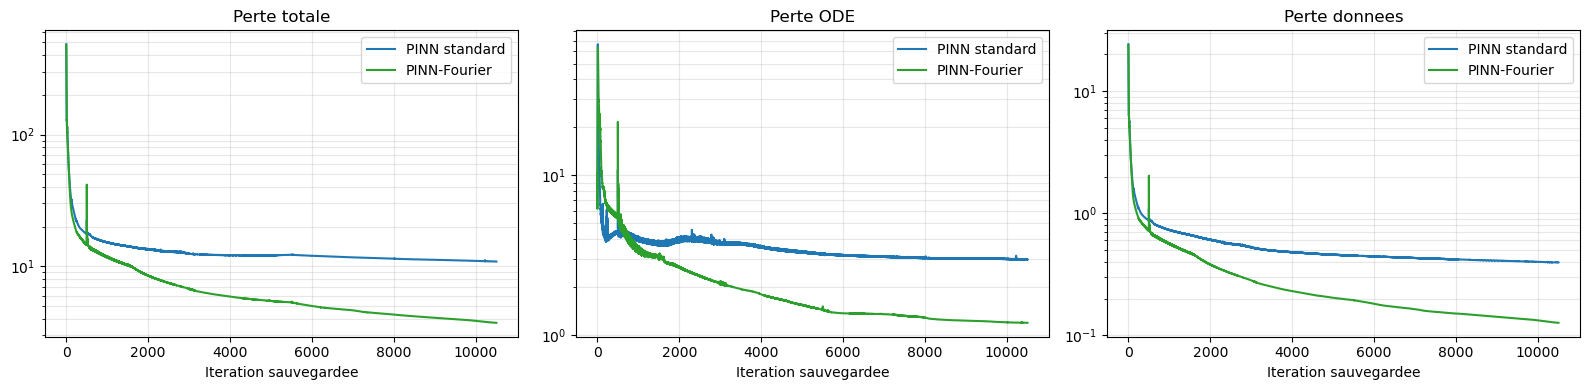

In [8]:
fig = plt.figure(figsize=(18, 6))

ax = fig.add_subplot(131, projection="3d")
ax.plot(x_ref, y_ref, z_ref, "k-", linewidth=0.7, label="RK45")
ax.scatter(*u0_np, color="red", s=60)
ax.set_title("RK45 reference")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

ax = fig.add_subplot(132, projection="3d")
ax.plot(U_std[:, 0], U_std[:, 1], U_std[:, 2], "tab:blue", linewidth=0.7, label="PINN standard")
ax.scatter(*u0_np, color="red", s=60)
ax.set_title("PINN standard")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

ax = fig.add_subplot(133, projection="3d")
ax.plot(U_fourier[:, 0], U_fourier[:, 1], U_fourier[:, 2], "tab:green", linewidth=0.7, label="PINN-Fourier")
ax.scatter(*u0_np, color="red", s=60)
ax.set_title("PINN-Fourier")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)

for i, comp in enumerate(component_names):
    axes[i, 0].plot(t_eval, U_ref[:, i], "k-", linewidth=1.2, label="RK45")
    axes[i, 0].plot(t_eval, U_std[:, i], "--", color="tab:blue", linewidth=1.0, label="PINN std")
    axes[i, 0].plot(t_eval, U_fourier[:, i], "--", color="tab:green", linewidth=1.0, label="PINN-FF")
    axes[i, 0].set_ylabel(comp)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].legend()

    axes[i, 1].semilogy(t_eval, np.abs(err_std[:, i]) + 1e-12, color="tab:blue", label="PINN std")
    axes[i, 1].semilogy(t_eval, np.abs(err_fourier[:, i]) + 1e-12, color="tab:green", label="PINN-FF")
    axes[i, 1].set_ylabel(f"Erreur {comp}")
    axes[i, 1].grid(True, alpha=0.3, which="both")
    if i == 0:
        axes[i, 1].legend()

axes[-1, 0].set_xlabel("Temps")
axes[-1, 1].set_xlabel("Temps")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, title in zip(axes, ["loss", "ode", "data"], ["Perte totale", "Perte ODE", "Perte donnees"]):
    ax.semilogy(hist_std[key], label="PINN standard", color="tab:blue")
    ax.semilogy(hist_fourier[key], label="PINN-Fourier", color="tab:green")
    ax.set_title(title)
    ax.set_xlabel("Iteration sauvegardee")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend()
plt.tight_layout()
plt.show()


## Lecture des resultats

Cette version corrige les principaux points experimentaux:

- la reference RK45 est utilisee comme reference numerique haute precision;
- le temps est normalise sur `[-1,1]`;
- les composantes `(X,Y,Z)` sont normalisees pour equilibrer les pertes;
- la condition initiale est imposee exactement par construction;
- les points de donnees et les points de collocation physique sont separes;
- l'entrainement utilise Adam avec scheduler; L-BFGS est laisse desactive par defaut pour eviter un cout trop eleve sur CPU;
- les metriques rapportent MAE, RMSE et erreur relative L2 par composante.

Pour le systeme de Lorenz, une erreur trajectorielle qui augmente avec le temps est normale:
le systeme est chaotique. L'analyse doit donc comparer a la fois la proximite a court terme,
le respect du residu differentiel et la geometrie de l'attracteur.
